<a href="https://colab.research.google.com/github/samrudhimadane6-creator/Customer-Segmentation/blob/main/Data_Cleaning_%26_Reporting_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = {
    "Customer_Name": ["Rahul", "Sneha", "Amit", "Priya", "Rohit"],
    "Age": [25, 22, 30, 27, 24],
    "City": ["Pune", "Mumbai", "Pune", "Nashik", "Mumbai"],
    "Product": ["Laptop", "Mobile", "Tablet", "Laptop", "Headphones"],
    "Sales": [55000, 25000, 18000, 60000, 5000],
    "Date": ["2026-01-10", "2026-01-15", "2026-02-05", "2026-02-12", "2026-02-20"]
}

df = pd.DataFrame(data)

print(df)

  Customer_Name  Age    City     Product  Sales        Date
0         Rahul   25    Pune      Laptop  55000  2026-01-10
1         Sneha   22  Mumbai      Mobile  25000  2026-01-15
2          Amit   30    Pune      Tablet  18000  2026-02-05
3         Priya   27  Nashik      Laptop  60000  2026-02-12
4         Rohit   24  Mumbai  Headphones   5000  2026-02-20


In [2]:
print(df.isnull().sum())

Customer_Name    0
Age              0
City             0
Product          0
Sales            0
Date             0
dtype: int64


In [3]:
df.loc[2, "Age"] = None
df.loc[4, "City"] = None
df.loc[3, "Sales"] = None

print(df)

  Customer_Name   Age    City     Product    Sales        Date
0         Rahul  25.0    Pune      Laptop  55000.0  2026-01-10
1         Sneha  22.0  Mumbai      Mobile  25000.0  2026-01-15
2          Amit   NaN    Pune      Tablet  18000.0  2026-02-05
3         Priya  27.0  Nashik      Laptop      NaN  2026-02-12
4         Rohit  24.0    None  Headphones   5000.0  2026-02-20


In [4]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["City"] = df["City"].fillna("Unknown")

df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

print(df)

  Customer_Name   Age     City     Product    Sales        Date
0         Rahul  25.0     Pune      Laptop  55000.0  2026-01-10
1         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15
2          Amit  24.5     Pune      Tablet  18000.0  2026-02-05
3         Priya  27.0   Nashik      Laptop  25750.0  2026-02-12
4         Rohit  24.0  Unknown  Headphones   5000.0  2026-02-20


In [5]:
print(df.isnull().sum())

Customer_Name    0
Age              0
City             0
Product          0
Sales            0
Date             0
dtype: int64


In [6]:
df = pd.concat([df, df.iloc[[1]]], ignore_index=True)

print(df)

  Customer_Name   Age     City     Product    Sales        Date
0         Rahul  25.0     Pune      Laptop  55000.0  2026-01-10
1         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15
2          Amit  24.5     Pune      Tablet  18000.0  2026-02-05
3         Priya  27.0   Nashik      Laptop  25750.0  2026-02-12
4         Rohit  24.0  Unknown  Headphones   5000.0  2026-02-20
5         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15


In [7]:
df = pd.concat([df, df.iloc[[1]]], ignore_index=True)

print(df)

  Customer_Name   Age     City     Product    Sales        Date
0         Rahul  25.0     Pune      Laptop  55000.0  2026-01-10
1         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15
2          Amit  24.5     Pune      Tablet  18000.0  2026-02-05
3         Priya  27.0   Nashik      Laptop  25750.0  2026-02-12
4         Rohit  24.0  Unknown  Headphones   5000.0  2026-02-20
5         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15
6         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [9]:
df = df.drop_duplicates()

print(df)

  Customer_Name   Age     City     Product    Sales        Date
0         Rahul  25.0     Pune      Laptop  55000.0  2026-01-10
1         Sneha  22.0   Mumbai      Mobile  25000.0  2026-01-15
2          Amit  24.5     Pune      Tablet  18000.0  2026-02-05
3         Priya  27.0   Nashik      Laptop  25750.0  2026-02-12
4         Rohit  24.0  Unknown  Headphones   5000.0  2026-02-20


In [10]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Customer_Name            object
Age                     float64
City                     object
Product                  object
Sales                   float64
Date             datetime64[ns]
dtype: object


In [11]:
total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 128750.0


In [12]:
average_sales = df["Sales"].mean()

print("Average Sales:", round(average_sales, 2))

Average Sales: 25750.0


In [13]:
product_sales = df.groupby("Product")["Sales"].sum()

print(product_sales)

Product
Headphones     5000.0
Laptop        80750.0
Mobile        25000.0
Tablet        18000.0
Name: Sales, dtype: float64


In [14]:
best_product = product_sales.idxmax()
best_sales = product_sales.max()

print("Best Product:", best_product)
print("Highest Sales:", best_sales)

Best Product: Laptop
Highest Sales: 80750.0


In [15]:
city_sales = df.groupby("City")["Sales"].sum()

print(city_sales)

City
Mumbai     25000.0
Nashik     25750.0
Pune       73000.0
Unknown     5000.0
Name: Sales, dtype: float64


NameError: name 'plt' is not defined

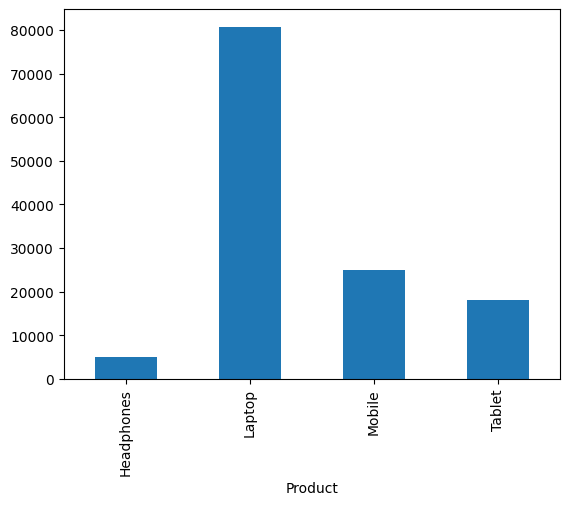

In [16]:
product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

NameError: name 'plt' is not defined

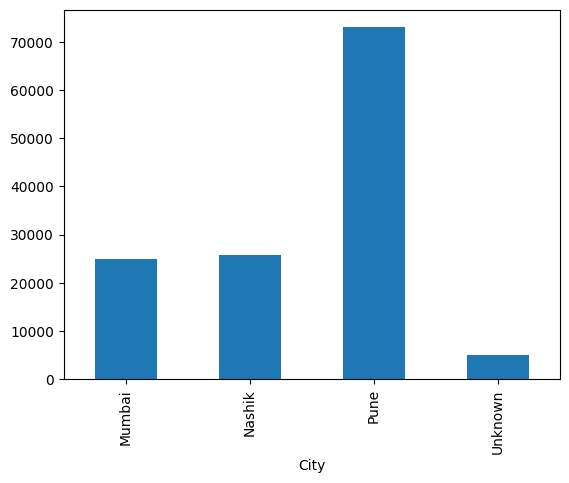

In [17]:
city_sales.plot(kind="bar")

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [18]:
print("Final Cleaned Dataset")
print(df)

Final Cleaned Dataset
  Customer_Name   Age     City     Product    Sales       Date
0         Rahul  25.0     Pune      Laptop  55000.0 2026-01-10
1         Sneha  22.0   Mumbai      Mobile  25000.0 2026-01-15
2          Amit  24.5     Pune      Tablet  18000.0 2026-02-05
3         Priya  27.0   Nashik      Laptop  25750.0 2026-02-12
4         Rohit  24.0  Unknown  Headphones   5000.0 2026-02-20


In [19]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned data saved successfully!")

Cleaned data saved successfully!


In [20]:
report = {
    "Total Sales": total_sales,
    "Average Sales": round(average_sales, 2),
    "Best Product": best_product,
    "Highest Product Sales": best_sales
}

report_df = pd.DataFrame([report])

print(report_df)

   Total Sales  Average Sales Best Product  Highest Product Sales
0     128750.0        25750.0       Laptop                80750.0


In [21]:
report_df.to_csv("sales_report.csv", index=False)

print("Report generated successfully!")

Report generated successfully!


In [22]:
from google.colab import files

files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>